# H&M LLM-Factor RecSys — End-to-end Demo

> **falsification-first** 연구 — 원래 가설(LLM 속성이 추천 *정확도*를 높인다)을 스스로 반증하고, 원인을 진단하고, *가치가 실제로 있는 곳*(merchant 의사결정 · 해석 가능한 결정-축 · 제어)으로 pivot한 전 과정.

이 노트북은 셋을 한 흐름으로 보여준다 — **① 연구 여정(Journey)** · **② 실제 활용(Product)** · **③ 정직한 분석(Analysis)**. 모든 수치·figure는 canonical `witnesses/probe_*_result.json`(고정 seed·bootstrap CI)에서 **로드**(재계산 없음)되어, 데이터 없이도 self-contained.

---
### 한눈에 보는 결론
| 축 | consumer-recsys lift | 근거 |
|---|:---:|---|
| accuracy · diversity · coverage · serendipity | **전 축 NEGATIVE** | probe_21/02/23 |
| merchant 의사결정-지원 (3 cell) | **POSITIVE** | r=0.472 · η=0.673 · η=0.631 |
| interpretable decision-axes · 제어 | **capability YES** | E2-1 · probe_15 |

> *capability vs prediction 분리*가 핵심 기여. 셀링포인트는 단일 정확도 수치가 아니라 **연구 성숙도**(falsification rigor + mechanism diagnosis + de-risk→scale 자기반증 + honest negative).

In [1]:
%load_ext autoreload
%autoreload 2
import json, sys
from pathlib import Path
PROJECT_ROOT = Path('.').absolute().parent
sys.path.insert(0, str(PROJECT_ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle
from matplotlib.lines import Line2D
from IPython.display import Image, display

WIT = PROJECT_ROOT / 'witnesses'; FIG = PROJECT_ROOT / 'results' / 'figures'
MERCH = PROJECT_ROOT / 'results' / 'tables' / 'merch_scenarios'; FIG.mkdir(parents=True, exist_ok=True)
def J(name): return json.loads((WIT / name).read_text())

# ---- cohesive design system (UI/UX) ----
INK='#1f2933'; MUTED='#7b8794'; GRIDC='#e9ecef'
POS='#2f9e44'; NEG='#e03131'; WARN='#f08c00'; PRI='#1c7ed6'; ACC='#7048e8'; NEUT='#adb5bd'
POS_L='#ebfbee'; NEG_L='#fff5f5'; PRI_L='#e7f5ff'; WARN_L='#fff9db'; GRAY_L='#f1f3f5'
plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'white','savefig.facecolor':'white',
    'axes.edgecolor':MUTED,'axes.linewidth':0.9,'axes.labelcolor':INK,'axes.titlecolor':INK,
    'text.color':INK,'xtick.color':MUTED,'ytick.color':MUTED,'xtick.labelsize':9,'ytick.labelsize':9,
    'font.size':10,'axes.titlesize':11,'axes.titleweight':'bold','axes.labelsize':9.5,
    'axes.grid':True,'grid.color':GRIDC,'grid.linewidth':0.9,'axes.axisbelow':True,
    'axes.spines.top':False,'axes.spines.right':False,'legend.frameon':False,'legend.fontsize':8.5,
    'figure.dpi':110,'savefig.dpi':150,'savefig.bbox':'tight','font.family':'DejaVu Sans',
})
def banner(fig, title, subtitle=None, x=0.012):
    fig.text(x, 1.012, title, fontsize=14, fontweight='bold', color=INK, ha='left', va='bottom')
    if subtitle: fig.text(x, 1.004, subtitle, fontsize=9.5, color=MUTED, ha='left', va='top')
def caption(fig, txt, x=0.012):
    fig.text(x, -0.02, txt, fontsize=7.8, color=MUTED, ha='left', va='top', style='italic')
def save(fig, name):
    fig.savefig(FIG / name, dpi=150, bbox_inches='tight'); return fig

# ---- load all canonical artifacts once ----
E2B=J('probe_E2b_result.json'); E2D=J('probe_E2d_gap_decision.json'); R10=J('probe_23_result.json')
from src.serving.merch_scenarios import ScenarioConfig, load_confidence_cards, build_all_briefs, build_brief
cfg=ScenarioConfig(matrix_path=PROJECT_ROOT/'data/knowledge/enrichment_v2/matrix_axes.parquet',
    train_path=PROJECT_ROOT/'data/processed/train_transactions.parquet',
    articles_path=PROJECT_ROOT/'data/processed/articles.parquet',
    canonical_e2=PROJECT_ROOT/'witnesses/probe_E2_result.json', canonical_e2b=PROJECT_ROOT/'witnesses/probe_E2b_result.json')
cards=load_confidence_cards(cfg)
print('design system ready | canonical loaded:', [k for k in ['E2B','E2D','R10']],
      '| confidence cards:', list(cards))

design system ready | canonical loaded: ['E2B', 'E2D', 'R10'] | confidence cards: ['trend_leadtime', 'launch_signal', 'copurchase_velocity']


## 1 · The Research Journey — 가설을 스스로 반증하고 가치를 재정의하다

대부분의 포트폴리오가 *positive 결과만* 큐레이션하는 것과 달리, 이 연구는 5단계로 **반증 → 진단 → pivot** 했다. 각 단계의 수치는 canonical probe에서 인용.

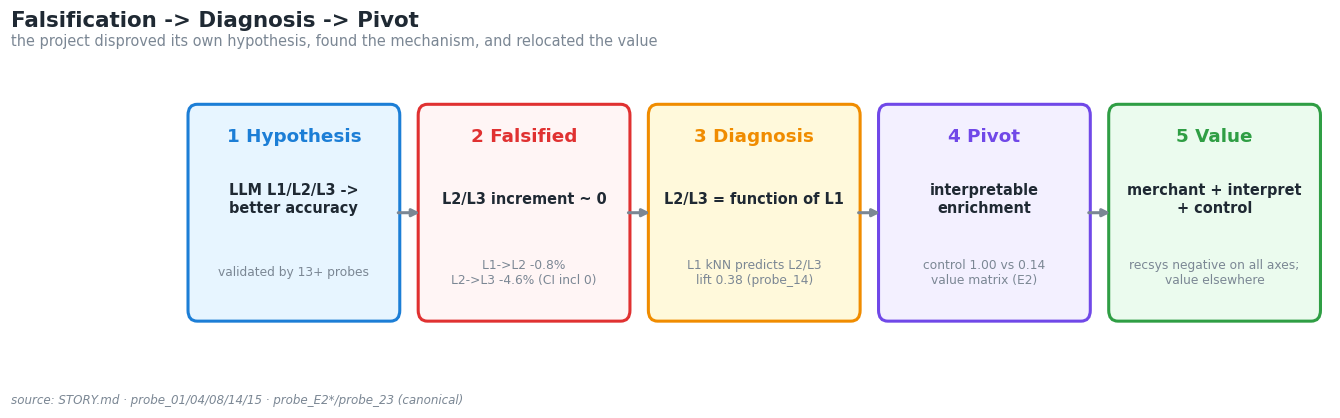

In [2]:
stages=[('1 Hypothesis','LLM L1/L2/L3 ->\nbetter accuracy','validated by 13+ probes',PRI,PRI_L),
        ('2 Falsified','L2/L3 increment ~ 0','L1->L2 -0.8%\nL2->L3 -4.6% (CI incl 0)',NEG,NEG_L),
        ('3 Diagnosis','L2/L3 = function of L1','L1 kNN predicts L2/L3\nlift 0.38 (probe_14)',WARN,WARN_L),
        ('4 Pivot','interpretable\nenrichment','control 1.00 vs 0.14\nvalue matrix (E2)',ACC,'#f3f0ff'),
        ('5 Value','merchant + interpret\n+ control','recsys negative on all axes;\nvalue elsewhere',POS,POS_L)]
fig,ax=plt.subplots(figsize=(13.5,3.2)); ax.set_xlim(0,len(stages)); ax.set_ylim(0,1); ax.axis('off')
for i,(t,h,sub,c,cl) in enumerate(stages):
    box=FancyBboxPatch((i+0.06,0.12),0.88,0.76,boxstyle='round,pad=0.02,rounding_size=0.04',
                       linewidth=2,edgecolor=c,facecolor=cl); ax.add_patch(box)
    ax.text(i+0.5,0.78,t,ha='center',va='center',fontsize=12,fontweight='bold',color=c)
    ax.text(i+0.5,0.55,h,ha='center',va='center',fontsize=9.5,fontweight='bold',color=INK)
    ax.text(i+0.5,0.28,sub,ha='center',va='center',fontsize=8,color=MUTED)
    if i<len(stages)-1: ax.annotate('',xy=(i+1.06,0.5),xytext=(i+0.94,0.5),
        arrowprops=dict(arrowstyle='-|>',color=MUTED,lw=2))
banner(fig,'Falsification -> Diagnosis -> Pivot',
       'the project disproved its own hypothesis, found the mechanism, and relocated the value')
caption(fig,'source: STORY.md · probe_01/04/08/14/15 · probe_E2*/probe_23 (canonical)')
save(fig,'07_research_arc.png'); plt.show()

### 데이터 맥락 — Triple-Sparsity & 카탈로그 구성

105K 아이템 카탈로그를 행동-파생 결정-축(trend phase · outfit role)으로 분해한 분포. 이 축들이 뒤의 머천다이징 brief의 grouping 변수다.

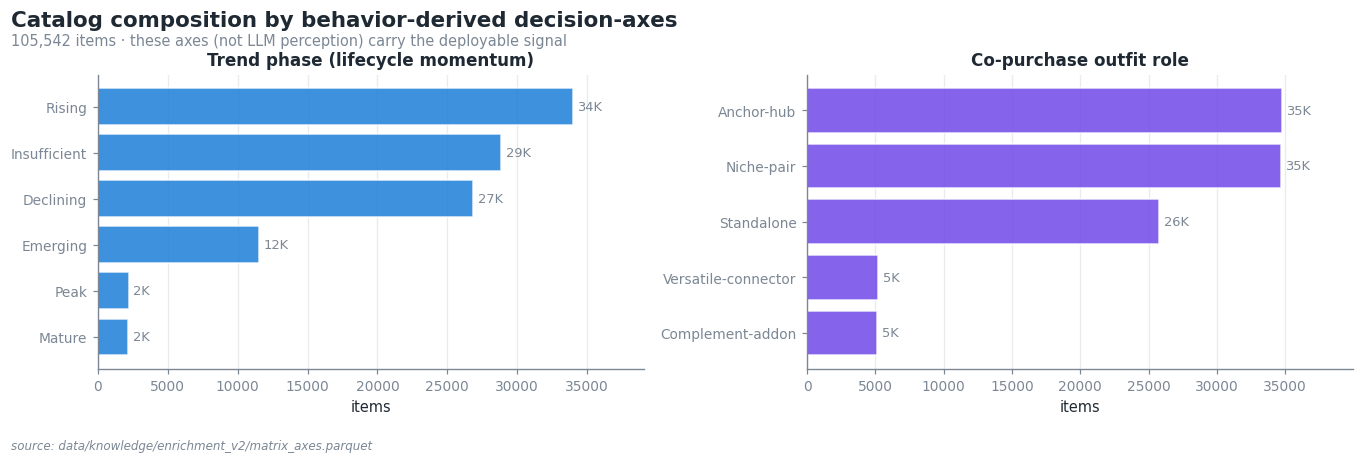

In [3]:
mx=pd.read_parquet(cfg.matrix_path)
fig,ax=plt.subplots(1,2,figsize=(12.5,3.6))
for a,col,ttl,c in [(ax[0],'e2_trend_phase_actual','Trend phase (lifecycle momentum)',PRI),
                    (ax[1],'e2_outfit_role','Co-purchase outfit role',ACC)]:
    vc=mx[col].value_counts().sort_values()
    bars=a.barh(vc.index,vc.values,color=c,alpha=0.85,edgecolor='white')
    a.bar_label(bars,labels=[f'{v/1000:.0f}K' for v in vc.values],padding=3,fontsize=8.5,color=MUTED)
    a.set_title(ttl); a.set_xlabel('items'); a.grid(axis='y',visible=False)
    a.set_xlim(0,vc.values.max()*1.15)
banner(fig,'Catalog composition by behavior-derived decision-axes',
       f'{len(mx):,} items · these axes (not LLM perception) carry the deployable signal')
caption(fig,'source: data/knowledge/enrichment_v2/matrix_axes.parquet')
plt.tight_layout(); save(fig,'07_catalog_composition.png'); plt.show()

## 2 · 실제 활용 — Merchandising 의사결정-지원 (배포 가능한 제품)

value matrix가 정직하게 닫은 **행동-검증 3 PASS cell**을 머천다이저가 쓰는 batch brief로 제품화(`src/serving/merch_scenarios.py`). confidence(r·η·CI)는 canonical에서 **로드**, 운영 테이블은 엔진이 live 계산.

| brief | 축 | 신호 | 머천다이저 활용 |
|---|---|---|---|
| **A** Trend lead-time | `trend_phase` | hot-share → sales **(t+3mo)** | 카테고리 수요-상승 조기경보 |
| **B** Launch scorecard | `trend_phase` | first-week sell-through | 신규 런칭 재고배분 |
| **C** Co-purchase velocity | `outfit_role` | sales velocity | anchor 랭킹 + 번들 |

### A · Trend lead-time — hot-share가 매출을 *3개월 선행*한다 (r=0.472)

카테고리의 hot(Emerging+Rising) 아이템 share가 그 카테고리 매출을 3개월 앞서 움직인다. 좌: lag별 상관(permutation null 대비, 3개월에서 peak). 우: 현재 hot-share z-score로 카테고리를 랭킹한 **실 운영 산출물**(high-alert/elevated 티어). buying/planning 팀에 3개월 조기경보를 주는 신호.

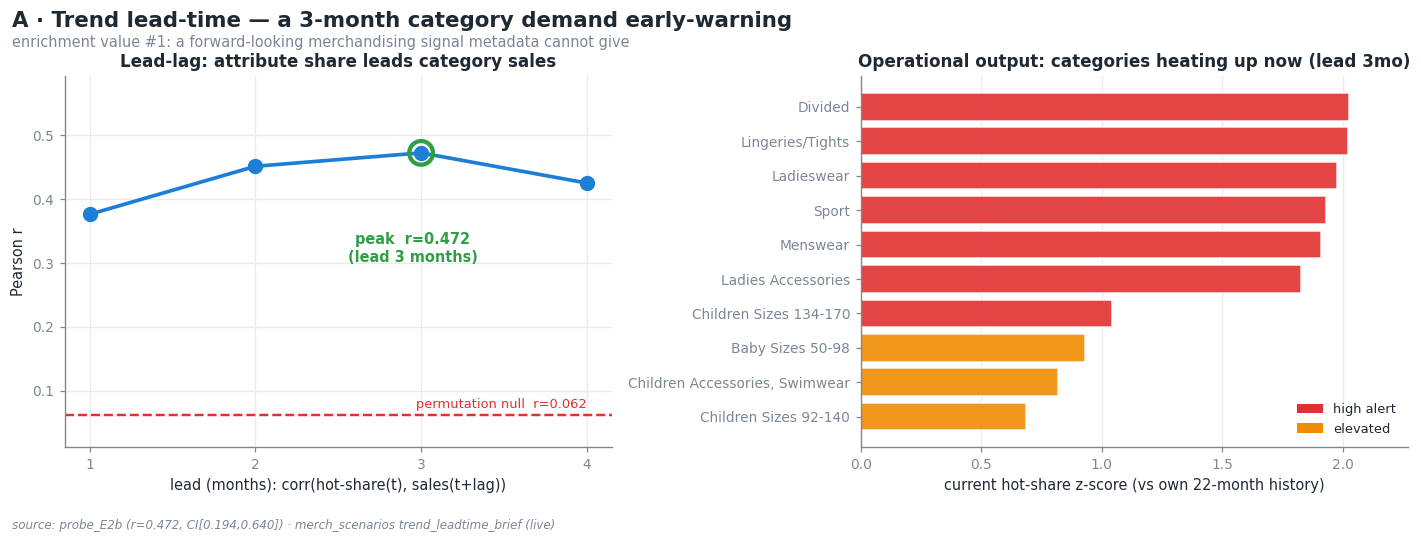

,category,latest_hot_share,hist_mean_share,share_zscore,share_trend_3mo,latest_month_sales,early_warning
0,Divided,0.8990,0.4321,2.028,0.2168,345212,high
1,Lingeries/Tights,0.9107,0.4601,2.022,0.1966,404460,high
2,Ladieswear,0.9128,0.4260,1.978,0.2042,736522,high
3,Sport,0.7791,0.3179,1.929,0.2239,55986,high
4,Menswear,0.8384,0.4373,1.911,0.2721,100933,high
5,Ladies Accessories,0.8181,0.4032,1.829,0.1811,97543,high


In [4]:
from matplotlib.patches import Patch
bA=build_brief('trend_leadtime', cfg)
lag=bA.extra['lead_lag_by_lag']; best=bA.extra['best_lag']; null_r=cards['trend_leadtime'].baseline
fig,ax=plt.subplots(1,2,figsize=(13,4.3))
# left: lag-correlation curve
ks=sorted(lag); rs=[lag[k] for k in ks]
ax[0].axhline(null_r,ls='--',lw=1.6,color=NEG,zorder=1)
ax[0].plot(ks,rs,'-o',color=PRI,lw=2.4,ms=9,zorder=3)
bi=ks.index(best); ax[0].scatter([best],[rs[bi]],s=240,facecolor='none',edgecolor=POS,lw=2.8,zorder=4)
ax[0].annotate(f'peak  r={rs[bi]:.3f}\n(lead {best} months)',xy=(best,rs[bi]),xytext=(best-0.05,rs[bi]-0.17),
    fontsize=9.5,fontweight='bold',color=POS,ha='center')
ax[0].text(ks[-1],null_r+0.012,f'permutation null  r={null_r:.3f}',ha='right',fontsize=8.5,color=NEG)
ax[0].set_xticks(ks); ax[0].set_xlabel('lead (months): corr(hot-share(t), sales(t+lag))')
ax[0].set_ylabel('Pearson r'); ax[0].set_title('Lead-lag: attribute share leads category sales')
ax[0].set_ylim(min(min(rs),null_r)-0.05, max(rs)+0.12)
# right: operational early-warning ranking (the actual brief A deliverable)
tb=bA.table.copy().sort_values('share_zscore').tail(10)
tiercol={'high':NEG,'elevated':WARN}
cols=[tiercol.get(str(t),NEUT) for t in tb['early_warning']]
ax[1].barh(tb['category'],tb['share_zscore'],color=cols,alpha=0.9,edgecolor='white')
ax[1].set_xlim(0,tb['share_zscore'].max()*1.12); ax[1].grid(axis='y',visible=False)
ax[1].set_xlabel('current hot-share z-score (vs own 22-month history)')
ax[1].set_title('Operational output: categories heating up now (lead 3mo)')
ax[1].legend(handles=[Patch(facecolor=NEG,label='high alert'),Patch(facecolor=WARN,label='elevated')],
    loc='lower right')
banner(fig,'A · Trend lead-time — a 3-month category demand early-warning',
       'enrichment value #1: a forward-looking merchandising signal metadata cannot give')
caption(fig,'source: probe_E2b (r=0.472, CI[0.194,0.640]) · merch_scenarios trend_leadtime_brief (live)')
plt.tight_layout(); save(fig,'07_trend_leadtime.png'); plt.show()
display(bA.table.head(6))

### B · C — Launch sell-through & Co-purchase velocity (η separation)

**B**: trend_phase가 신규 런칭 first-week sell-through를 가른다(η=0.673). **C**: outfit_role이 sales velocity를 가른다(η=0.631). 아래 분포는 그 group separation을 *직접* 보여준다 — brief는 이를 티어 스코어카드로 운영.

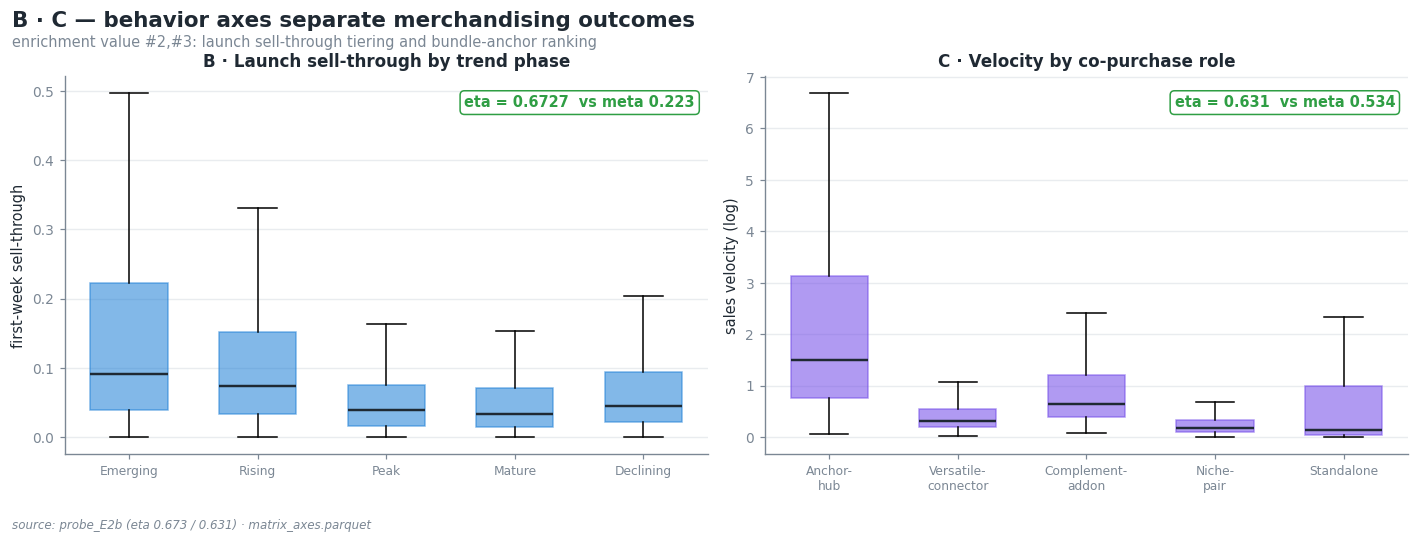

In [5]:
PHASE_ORD=['Emerging','Rising','Peak','Mature','Declining']
ROLE_ORD=['Anchor-hub','Versatile-connector','Complement-addon','Niche-pair','Standalone']
fig,ax=plt.subplots(1,2,figsize=(13,4.3))
def grouped_box(a,col,order,ycol,ylab,ttl,base,eta,c):
    sub=mx[mx[col].isin(order) & mx[ycol].notna()]
    data=[sub.loc[sub[col]==g,ycol].values for g in order]
    bp=a.boxplot(data,widths=0.6,patch_artist=True,showfliers=False,
                 medianprops=dict(color=INK,lw=1.6))
    for patch in bp['boxes']: patch.set(facecolor=c,alpha=0.55,edgecolor=c)
    a.set_xticks(range(1,len(order)+1)); a.set_xticklabels([g.replace('-','-\n') for g in order],fontsize=8)
    a.set_ylabel(ylab); a.set_title(ttl); a.grid(axis='x',visible=False)
    a.text(0.98,0.95,f'eta = {eta}  vs meta {base}',transform=a.transAxes,ha='right',va='top',
           fontsize=9.5,fontweight='bold',color=POS,bbox=dict(boxstyle='round,pad=0.3',fc='white',ec=POS))
grouped_box(ax[0],'e2_trend_phase_actual',PHASE_ORD,'first_week_sell_through',
    'first-week sell-through','B · Launch sell-through by trend phase',0.223,cards['launch_signal'].value,PRI)
vsub=mx.copy(); vsub['velocity']=np.log1p(vsub['velocity'])
grouped_box(ax[1],'e2_outfit_role',ROLE_ORD,'velocity',
    'sales velocity (log)','C · Velocity by co-purchase role',0.534,cards['copurchase_velocity'].value,ACC)
banner(fig,'B · C — behavior axes separate merchandising outcomes',
       'enrichment value #2,#3: launch sell-through tiering and bundle-anchor ranking')
caption(fig,'source: probe_E2b (eta 0.673 / 0.631) · matrix_axes.parquet')
plt.tight_layout(); save(fig,'07_merch_distributions.png'); plt.show()

## 3 · 정직한 분석 — 무엇이 *안 되는지* (negatives)

제품 3 cell이 어디까지 유효한지는 **무엇이 안 되는지**를 정직하게 보여줘야 의미가 있다. value matrix 전체 + 이번 연구의 두 핵심 negative(serendipity R-10, gap E2-5) + 전 축 가치지도.

### 3.1 Value matrix — capability(14/16, dense) vs decision-lift(3/16, sparse)

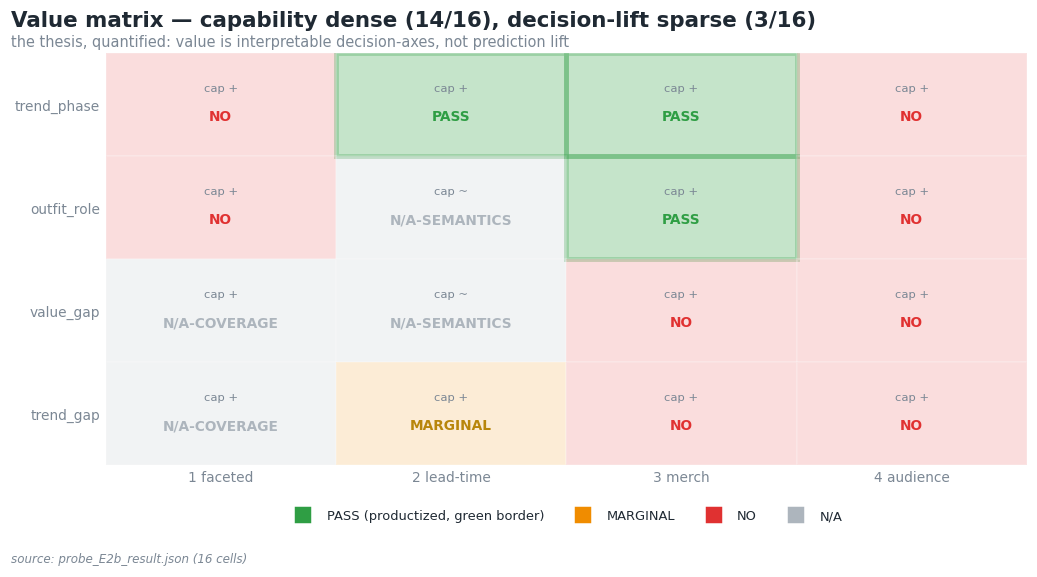

In [6]:
AX=['e2_trend_phase_actual','e2_outfit_role','e2_value_gap','e2_trend_gap']
US=['faceted','leadlag','merch','audience']
VC={'PASS':POS,'MARGINAL':WARN,'NO':NEG,'N/A-SEMANTICS':NEUT,'N/A-DATA':NEUT,'N/A-COVERAGE':NEUT}
by={}
for c in E2B['value_matrix']:
    a=c['axis'].replace('_sign',''); by[(a,c['use'])]=c
fig,ax=plt.subplots(figsize=(9.5,4.6))
for i,a in enumerate(AX):
    for j,u in enumerate(US):
        c=by.get((a,u),{}); v=c.get('lift_verdict','NO'); cap=c.get('capability','')
        col=VC.get(v,NEUT); is_pass=(v=='PASS')
        ax.add_patch(Rectangle((j,i),1,1,facecolor=col,alpha=0.16 if not is_pass else 0.28,
            edgecolor=POS if is_pass else 'white',lw=3.2 if is_pass else 1.4))
        capg={'YES':'cap +','PARTIAL':'cap ~','NO':'cap -'}.get(cap,'')
        ax.text(j+0.5,i+0.62,v,ha='center',va='center',fontsize=9,fontweight='bold',
                color=col if v!='MARGINAL' else '#b8860b')
        ax.text(j+0.5,i+0.34,capg,ha='center',va='center',fontsize=7.5,color=MUTED)
ax.set_xlim(0,4); ax.set_ylim(0,4); ax.invert_yaxis()
ax.set_xticks(np.arange(4)+0.5); ax.set_xticklabels(['1 faceted','2 lead-time','3 merch','4 audience'])
ax.set_yticks(np.arange(4)+0.5); ax.set_yticklabels([a.replace('e2_','').replace('_actual','') for a in AX])
ax.tick_params(length=0); [s.set_visible(False) for s in ax.spines.values()]; ax.grid(False)
leg=[Line2D([0],[0],marker='s',color='w',markerfacecolor=POS,ms=12,label='PASS (productized, green border)'),
     Line2D([0],[0],marker='s',color='w',markerfacecolor=WARN,ms=12,label='MARGINAL'),
     Line2D([0],[0],marker='s',color='w',markerfacecolor=NEG,ms=12,label='NO'),
     Line2D([0],[0],marker='s',color='w',markerfacecolor=NEUT,ms=12,label='N/A')]
ax.legend(handles=leg,loc='upper center',bbox_to_anchor=(0.5,-0.08),ncol=4,fontsize=8.5)
banner(fig,'Value matrix — capability dense (14/16), decision-lift sparse (3/16)',
       'the thesis, quantified: value is interpretable decision-axes, not prediction lift')
caption(fig,'source: probe_E2b_result.json (16 cells)')
plt.tight_layout(); save(fig,'07_value_matrix.png'); plt.show()

### 3.2 Serendipity / Novelty — 마지막 열린 차원도 negative (R-10)

정확도·diversity·coverage가 닫힌 뒤 남은 *유일한* recsys 차원(serendipity = relevant ∧ surprising)도 full-catalog 105K·25K user에서 falsify. **novelty 함정**이 핵심: novelty는 비관련 인기-낮은 아이템으로 trivially 오른다 — random-12가 novelty 최고지만 serendipitous hit ≈0. 그래서 headline은 relevance-grounded.

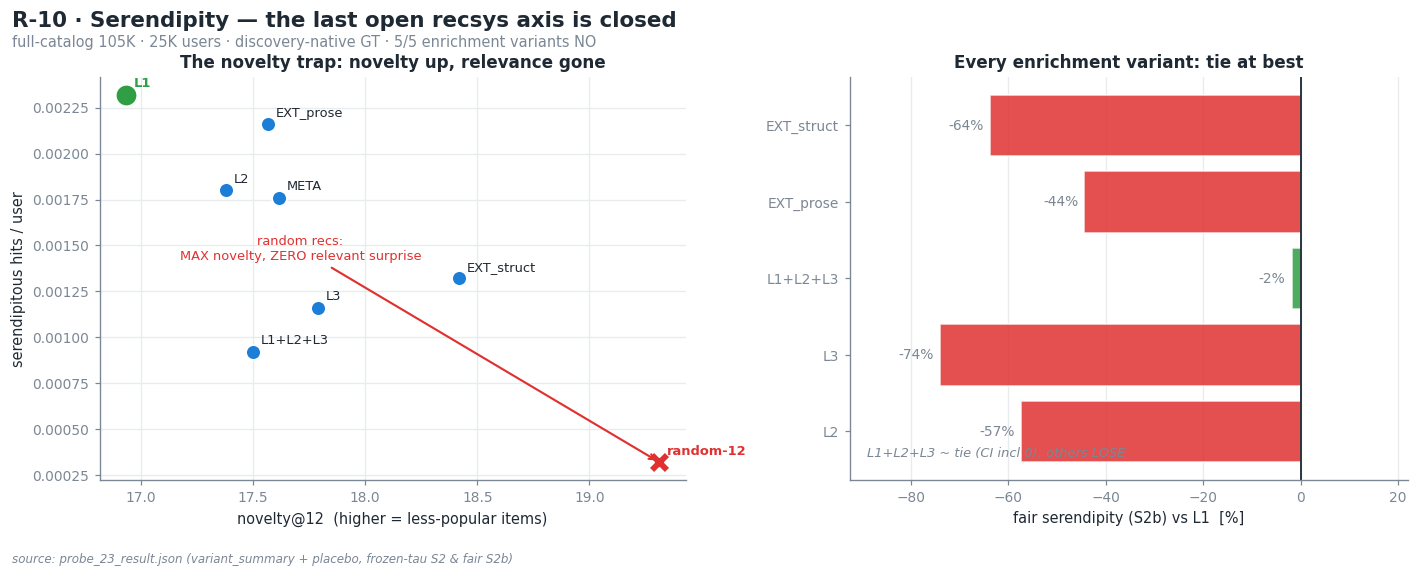

In [7]:
s=R10['variant_summary']; pl=R10['placebo_random12']
fig=plt.figure(figsize=(13,4.6)); gs=fig.add_gridspec(1,2,width_ratios=[1.05,1])
axL=fig.add_subplot(gs[0]); axR=fig.add_subplot(gs[1])
# left: novelty vs serendipity scatter (the dissociation)
pts={**{k:(v['novelty_at_12'],v['seren_hits_per_user']) for k,v in s.items()},
     'random-12':(pl['novelty_at_12'],pl['seren_hits_per_user'])}
for k,(x,y) in pts.items():
    is_pl=k=='random-12'; is_l1=k=='L1'
    axL.scatter(x,y,s=200 if (is_pl or is_l1) else 95,
        color=NEG if is_pl else (POS if is_l1 else PRI),
        marker='X' if is_pl else 'o',zorder=3,edgecolor='white',lw=1.2)
    axL.annotate(k,(x,y),xytext=(5,5),textcoords='offset points',fontsize=8.5,
        fontweight='bold' if (is_pl or is_l1) else 'normal',
        color=NEG if is_pl else (POS if is_l1 else INK))
axL.set_xlabel('novelty@12  (higher = less-popular items)'); axL.set_ylabel('serendipitous hits / user')
axL.set_title('The novelty trap: novelty up, relevance gone')
axL.annotate('random recs:\nMAX novelty, ZERO relevant surprise',xy=pts['random-12'],
    xytext=(pts['random-12'][0]-1.6,pts['random-12'][1]+0.0011),fontsize=8.5,color=NEG,ha='center',
    arrowprops=dict(arrowstyle='->',color=NEG,lw=1.4))
# right: S2b (fair serendipity) vs L1, all variants lose-or-tie
ev=['L2','L3','L1+L2+L3','EXT_prose','EXT_struct']
rel=[(s[v]['seren_hits_sym_per_user']-s['L1']['seren_hits_sym_per_user'])/s['L1']['seren_hits_sym_per_user']*100 for v in ev]
cols=[POS if abs(r)<5 else NEG for r in rel]
bars=axR.barh(ev,rel,color=cols,alpha=0.85,edgecolor='white')
axR.axvline(0,color=INK,lw=1.2); axR.bar_label(bars,labels=[f'{r:+.0f}%' for r in rel],padding=4,fontsize=9,color=MUTED)
axR.set_xlabel('fair serendipity (S2b) vs L1  [%]'); axR.set_title('Every enrichment variant: tie at best')
axR.set_xlim(min(rel)*1.25,22); axR.grid(axis='y',visible=False)
axR.text(0.03,0.06,'L1+L2+L3 ~ tie (CI incl 0); others LOSE',transform=axR.transAxes,ha='left',
    fontsize=8.5,color=MUTED,style='italic')
banner(fig,'R-10 · Serendipity — the last open recsys axis is closed',
       'full-catalog 105K · 25K users · discovery-native GT · 5/5 enrichment variants NO')
caption(fig,'source: probe_23_result.json (variant_summary + placebo, frozen-tau S2 & fair S2b)')
plt.tight_layout(); save(fig,'07_serendipity.png'); plt.show()

### 3.3 Gap decision-lift — forest plot (E2-5)

perception×behavior gap축(value_gap/trend_gap)이 *미래* 결정(markdown·sell-through·survival)을 자기 구성축 대비 움직이나? 5/5 cell 모두 사전등록 margin(0.01) 미달, CI가 0/margin을 가로지름 → gap = 해석 좌표지 예측축 아님.

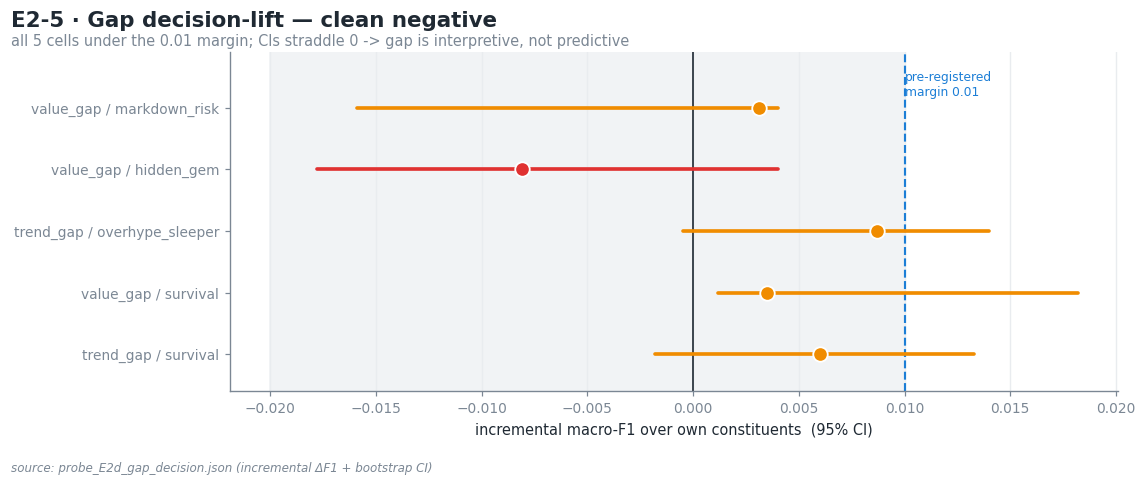

In [8]:
rows=[]
for c in E2D['value_matrix']:
    i=c.get('incremental') or {}
    if i.get('incr_delta_f1') is None: continue
    rows.append((c['axis'].replace('e2_','')+' / '+c['use'].replace('decision:',''),
                 i['incr_delta_f1'], i['acc_ci'][0], i['acc_ci'][1], c['lift_verdict']))
rows=rows[::-1]
fig,ax=plt.subplots(figsize=(10.5,3.8))
y=np.arange(len(rows))
ax.axvspan(-0.02,0.01,color=GRAY_L,zorder=0)
ax.axvline(0,color=INK,lw=1.1); ax.axvline(0.01,color=PRI,ls='--',lw=1.4)
ax.text(0.01,len(rows)-0.4,'pre-registered\nmargin 0.01',color=PRI,fontsize=8,ha='left',va='top')
for k,(lab,d,lo,hi,v) in enumerate(rows):
    c=WARN if v=='MARGINAL' else NEG
    ax.plot([lo,hi],[k,k],color=c,lw=2.4,solid_capstyle='round',zorder=2)
    ax.scatter([d],[k],s=90,color=c,zorder=3,edgecolor='white',lw=1.2)
ax.set_yticks(y); ax.set_yticklabels([r[0] for r in rows]); ax.set_ylim(-0.6,len(rows)-0.1)
ax.set_xlabel('incremental macro-F1 over own constituents  (95% CI)'); ax.grid(axis='y',visible=False)
banner(fig,'E2-5 · Gap decision-lift — clean negative',
       'all 5 cells under the 0.01 margin; CIs straddle 0 -> gap is interpretive, not predictive')
caption(fig,'source: probe_E2d_gap_decision.json (incremental ΔF1 + bootstrap CI)')
plt.tight_layout(); save(fig,'07_gap_forest.png'); plt.show()

### 3.4 추천 가치지도 — 전 축 정직한 정리 (scorecard)

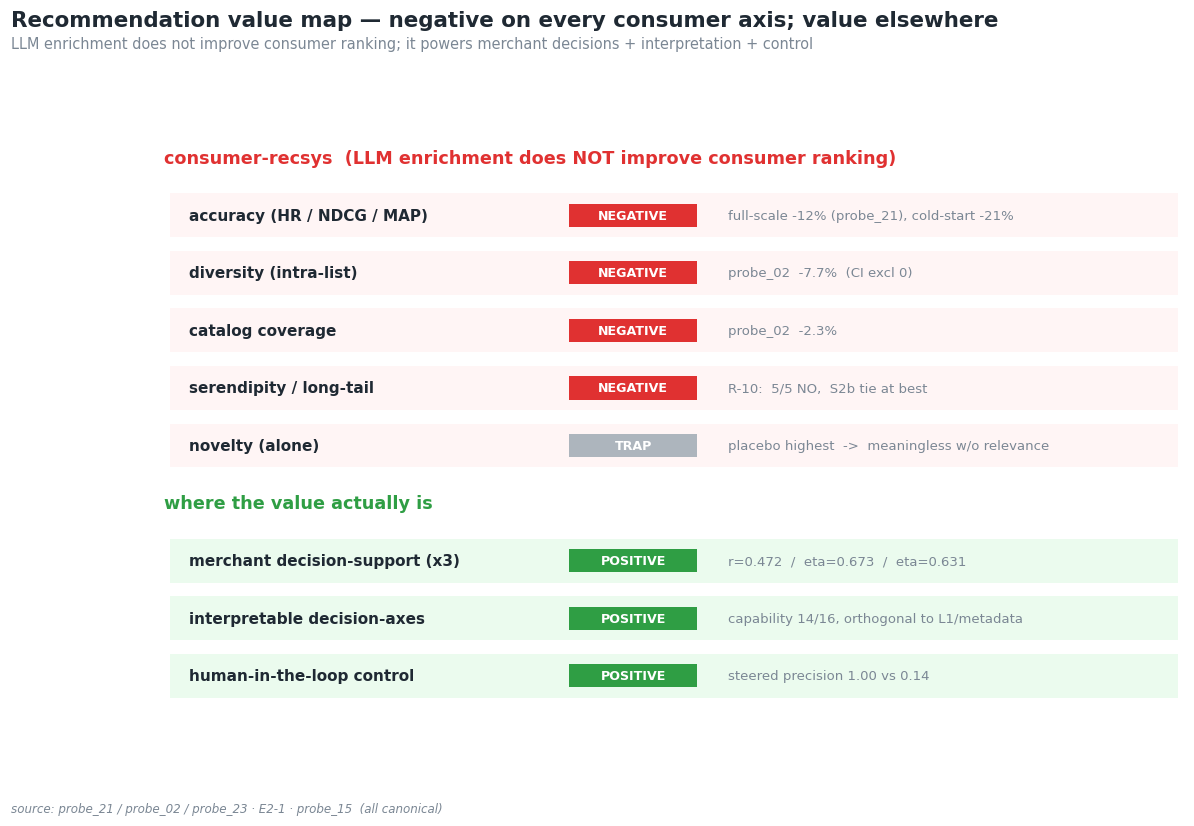

In [9]:
groups=[('consumer-recsys  (LLM enrichment does NOT improve consumer ranking)',NEG,NEG_L,[
    ('accuracy (HR / NDCG / MAP)','NEGATIVE','full-scale -12% (probe_21), cold-start -21%'),
    ('diversity (intra-list)','NEGATIVE','probe_02  -7.7%  (CI excl 0)'),
    ('catalog coverage','NEGATIVE','probe_02  -2.3%'),
    ('serendipity / long-tail','NEGATIVE','R-10:  5/5 NO,  S2b tie at best'),
    ('novelty (alone)','TRAP','placebo highest  ->  meaningless w/o relevance')]),
  ('where the value actually is',POS,POS_L,[
    ('merchant decision-support (x3)','POSITIVE','r=0.472  /  eta=0.673  /  eta=0.631'),
    ('interpretable decision-axes','POSITIVE','capability 14/16, orthogonal to L1/metadata'),
    ('human-in-the-loop control','POSITIVE','steered precision 1.00 vs 0.14')])]
cmap={'NEGATIVE':NEG,'TRAP':NEUT,'POSITIVE':POS}
items=[]
for hdr,hc,hl,rows in groups:
    items.append(('h',hdr,hc,None,None))
    for nm,vd,ev in rows: items.append(('r',nm,vd,ev,hl))
n=len(items)
fig,ax=plt.subplots(figsize=(12,0.62*n+0.6)); ax.set_xlim(0,1); ax.set_ylim(0,n); ax.invert_yaxis(); ax.axis('off')
for k,(kind,a,b,ev,hl) in enumerate(items):
    yc=k+0.5
    if kind=='h':
        ax.text(0.004,yc,a,fontsize=11.5,fontweight='bold',color=b,va='center')
    else:
        c=cmap[b]
        ax.add_patch(Rectangle((0.01,k+0.12),0.985,0.76,facecolor=hl,edgecolor='none'))
        ax.text(0.028,yc,a,fontsize=10,fontweight='bold',color=INK,va='center')
        ax.add_patch(Rectangle((0.40,k+0.30),0.125,0.40,facecolor=c,edgecolor='none'))
        ax.text(0.4625,yc,b,fontsize=8.3,fontweight='bold',color='white',ha='center',va='center')
        ax.text(0.555,yc,ev,fontsize=8.7,color=MUTED,va='center')
banner(fig,'Recommendation value map — negative on every consumer axis; value elsewhere',
       'LLM enrichment does not improve consumer ranking; it powers merchant decisions + interpretation + control')
caption(fig,'source: probe_21 / probe_02 / probe_23 · E2-1 · probe_15  (all canonical)')
save(fig,'07_value_map.png'); plt.show()

## 4 · 결론

**enrichment 속성의 가치 위치가 셀 단위로 확정됐다:**

- ✅ **제품 (실제 활용):** 행동-파생 3 cell → 배포 가능한 머천다이징 brief (3개월 조기경보 · launch 스코어카드 · anchor 랭킹).
- ✅ **해석 결정-축:** metadata·L1과 직교(capability 14/16) — 해석/감사/제어 표면.
- ✅ **제어:** human-in-the-loop steering (precision 1.00 vs 0.14), metadata엔 없음.
- ❌ **소비자-추천 lift:** 정확도·diversity·coverage·serendipity·novelty **전 축 negative**.

> **capability vs prediction 분리**가 핵심 기여. 그리고 그 negative들을 force-fit 없이 사전등록 margin·placebo·적대 audit으로 **정직하게 기록**한 *과정*이 셀링포인트다.

*제품 상세 → `notebooks/06_merch_scenario.ipynb` · 서사 → `docs/research_design/STORY.md` · canonical → `witnesses/probe_*_result.json`*